# Spliting exploration

- how much data do we want to put in our test split to get reliable performance metrics?

Things I want to be able to measure: 
- Performance over both small-scale and insustrial irrigation (no need to worry about the other categories). Statistically significant differences? 
- Is performance statistically significantly different across different months? Different years? Different climatological regions? 
- Are we capable of not just estimating irrigation well at one point in time, or can we actually pick up on change year to year? (we need enough examples with more than one image in the same location to be able to do this)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
irrigation_df = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv')
polygons_df = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_polygons_table.csv')

# Filter to KL only (designated test set labeler)
kl_irrigation = irrigation_df[irrigation_df['operator_initials'] == 'KL'].copy()
kl_polygons = polygons_df[polygons_df['operator_initials'] == 'KL'].copy()

# Create unique image identifier
kl_irrigation['image_id'] = (kl_irrigation['site_id'] + '_' + 
                              kl_irrigation['year'].astype(str) + '-' + 
                              kl_irrigation['month'].astype(str).str.zfill(2) + '-' + 
                              kl_irrigation['day'].astype(str).str.zfill(2))
kl_polygons['image_id'] = (kl_polygons['site_id'] + '_' + 
                           kl_polygons['year'].astype(str) + '-' + 
                           kl_polygons['month'].astype(str).str.zfill(2) + '-' + 
                           kl_polygons['day'].astype(str).str.zfill(2))

print("KL Dataset Overview:")
print(f"  Total images: {len(kl_irrigation)}")
print(f"  Total locations: {kl_irrigation['site_id'].nunique()}")
print(f"  Total polygons: {len(kl_polygons)}")

KL Dataset Overview:
  Total images: 681
  Total locations: 265
  Total polygons: 961


## 1. Small-scale vs Industrial Irrigation

How many images/polygons do we have of each category?

In [28]:
# Category breakdown in KL polygons
print("Polygon counts by category:")
print(kl_polygons['category'].value_counts())
print()

# For images: check which have small-scale vs industrial irrigation
# An image can have both - let's check coverage columns
print("Images with small-scale irrigation (percent_coverage_hc_small-scale > 0):")
n_smallscale = (kl_irrigation['percent_coverage_hc_small-scale'] > 0).sum()
print(f"  {n_smallscale} images")

print("\nImages with industrial irrigation (percent_coverage_hc_industrial > 0):")
n_industrial = (kl_irrigation['percent_coverage_hc_industrial'] > 0).sum()
print(f"  {n_industrial} images")

print("\nImages with any irrigation (irrigation > 2):")
n_irrigated = (kl_irrigation['irrigation'] > 2).sum()
print(f"  {n_irrigated} images")

print("\n" + "="*60)
print("CONCERN: Very few industrial irrigation examples in KL's labels.")
print("This limits our ability to compare small-scale vs industrial performance.")

Polygon counts by category:
category
small-scale    909
covered         21
industrial      19
tree_crop        8
lawn             4
Name: count, dtype: int64

Images with small-scale irrigation (percent_coverage_hc_small-scale > 0):
  177 images

Images with industrial irrigation (percent_coverage_hc_industrial > 0):
  18 images

Images with any irrigation (irrigation > 2):
  192 images

CONCERN: Very few industrial irrigation examples in KL's labels.
This limits our ability to compare small-scale vs industrial performance.


## 2. Monthly and Yearly Breakdown

For detecting statistically significant differences across time periods, we need sufficient samples in each group.

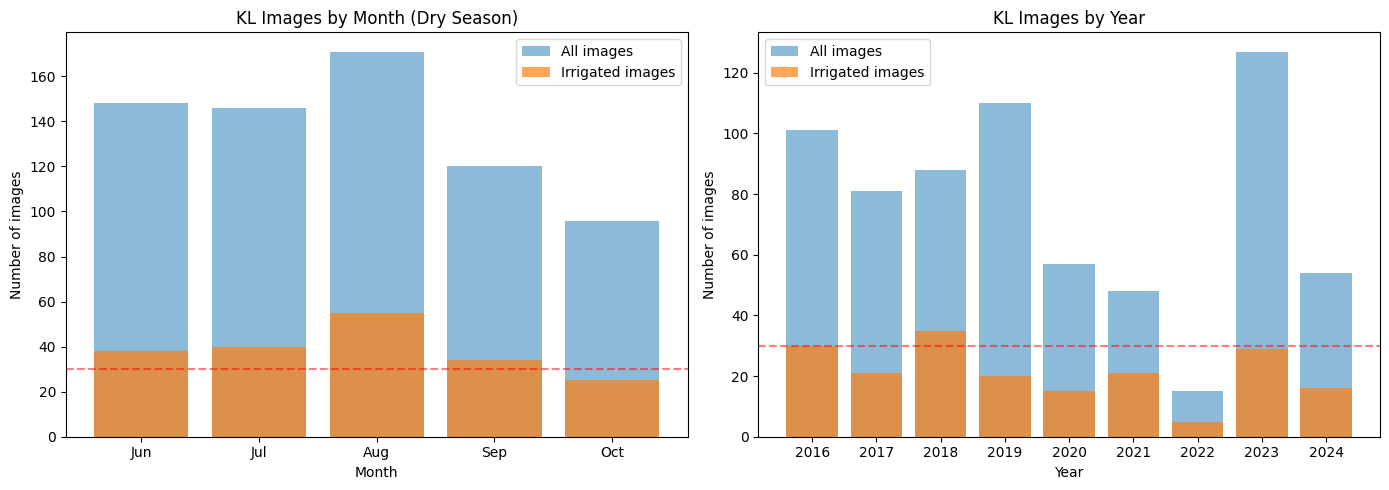

Monthly sample sizes - dry season only (irrigated / total):
  Jun: 38 / 148
  Jul: 40 / 146
  Aug: 55 / 171
  Sep: 34 / 120
  Oct: 25 / 96

Yearly sample sizes (irrigated / total):
  2016: 30 / 101
  2017: 21 / 81
  2018: 35 / 88
  2019: 20 / 110
  2020: 15 / 57
  2021: 21 / 48
  2022: 5 / 15
  2023: 29 / 127
  2024: 16 / 54


In [29]:
# Monthly breakdown (dry season only: June-October)
# Note: irrigation >= 3 means irrigated (certainty 3+)
month_names = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct']
month_nums = [6, 7, 8, 9, 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All images by month
ax = axes[0]
monthly_counts = kl_irrigation.groupby('month').size()
monthly_irrigated = kl_irrigation[kl_irrigation['irrigation'] >= 3].groupby('month').size()

ax.bar(range(len(month_nums)), [monthly_counts.get(m, 0) for m in month_nums], alpha=0.5, label='All images')
ax.bar(range(len(month_nums)), [monthly_irrigated.get(m, 0) for m in month_nums], alpha=0.7, label='Irrigated images')
ax.set_xlabel('Month')
ax.set_ylabel('Number of images')
ax.set_title('KL Images by Month (Dry Season)')
ax.set_xticks(range(len(month_nums)))
ax.set_xticklabels(month_names)
ax.legend()
ax.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='n=30 threshold')

# Yearly breakdown
ax = axes[1]
yearly_counts = kl_irrigation.groupby('year').size()
yearly_irrigated = kl_irrigation[kl_irrigation['irrigation'] >= 3].groupby('year').size()
years = sorted(yearly_counts.index)
ax.bar(range(len(years)), [yearly_counts.get(y, 0) for y in years], alpha=0.5, label='All images')
ax.bar(range(len(years)), [yearly_irrigated.get(y, 0) for y in years], alpha=0.7, label='Irrigated images')
ax.set_xlabel('Year')
ax.set_ylabel('Number of images')
ax.set_title('KL Images by Year')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.legend()
ax.axhline(y=30, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Monthly sample sizes - dry season only (irrigated / total):")
for i, m in enumerate(month_nums):
    total = monthly_counts.get(m, 0)
    irr = monthly_irrigated.get(m, 0)
    print(f"  {month_names[i]}: {irr} / {total}")

print("\nYearly sample sizes (irrigated / total):")
for y in sorted(yearly_counts.index):
    total = yearly_counts.get(y, 0)
    irr = yearly_irrigated.get(y, 0)
    print(f"  {y}: {irr} / {total}")

## 3. Temporal Change Detection

To assess whether the model can pick up year-to-year changes, we need locations with multiple images across different years.

Locations by number of images:
n_images
1     91
2     79
3     45
4     16
5     11
6      9
7      2
8      5
10     7
Name: count, dtype: int64

Locations by number of distinct years:
n_years
1    92
2    94
3    46
4    14
5    11
6     7
7     1
Name: count, dtype: int64

TEMPORAL CHANGE DETECTION CAPACITY

Locations with >1 image: 174
  ...with irrigation in at least one image: 65
  ...with BOTH irrigated AND non-irrigated images: 40
      (These locations allow us to assess change detection)

Locations with 2+ years of data: 173
  ...with BOTH irrigated AND non-irrigated images: 40


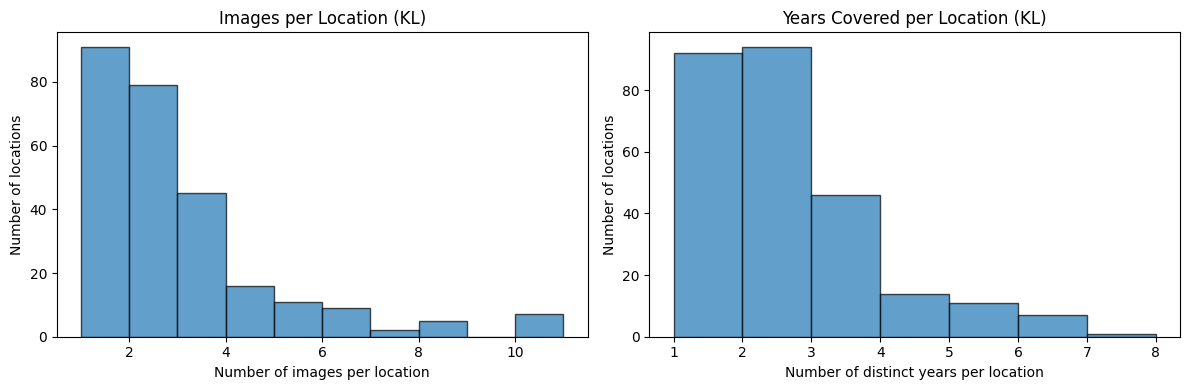

In [30]:
# Analyze temporal coverage per location
# Note: irrigation >= 3 means irrigated (certainty 3+)
location_stats = kl_irrigation.groupby('site_id').agg({
    'year': ['nunique', 'min', 'max', 'count'],
    'irrigation': [lambda x: (x >= 3).any(),  # Has any irrigation
                   lambda x: (x < 3).any()]   # Has any non-irrigation
}).reset_index()
location_stats.columns = ['site_id', 'n_years', 'min_year', 'max_year', 'n_images', 
                          'has_irrigation', 'has_no_irrigation']
location_stats['year_span'] = location_stats['max_year'] - location_stats['min_year']

# Key: locations with BOTH irrigated and non-irrigated images (can assess change detection)
location_stats['has_variation'] = location_stats['has_irrigation'] & location_stats['has_no_irrigation']

print("Locations by number of images:")
print(location_stats['n_images'].value_counts().sort_index())

print("\nLocations by number of distinct years:")
print(location_stats['n_years'].value_counts().sort_index())

print("\n" + "="*60)
print("TEMPORAL CHANGE DETECTION CAPACITY")
print("="*60)

# Locations with multiple images
multi_image = location_stats[location_stats['n_images'] > 1]
print(f"\nLocations with >1 image: {len(multi_image)}")

# Of those, how many have irrigation in at least one?
multi_image_with_irr = multi_image[multi_image['has_irrigation']]
print(f"  ...with irrigation in at least one image: {len(multi_image_with_irr)}")

# Of those, how many ALSO have a non-irrigated image? (can detect change)
multi_image_with_variation = multi_image[multi_image['has_variation']]
print(f"  ...with BOTH irrigated AND non-irrigated images: {len(multi_image_with_variation)}")
print(f"      (These locations allow us to assess change detection)")

# Multi-year specifically
print(f"\nLocations with 2+ years of data: {len(location_stats[location_stats['n_years'] >= 2])}")
multi_year_variation = location_stats[(location_stats['n_years'] >= 2) & location_stats['has_variation']]
print(f"  ...with BOTH irrigated AND non-irrigated images: {len(multi_year_variation)}")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(location_stats['n_images'], bins=range(1, location_stats['n_images'].max()+2), 
        edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of images per location')
ax.set_ylabel('Number of locations')
ax.set_title('Images per Location (KL)')

ax = axes[1]
ax.hist(location_stats['n_years'], bins=range(1, location_stats['n_years'].max()+2), 
        edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of distinct years per location')
ax.set_ylabel('Number of locations')
ax.set_title('Years Covered per Location (KL)')

plt.tight_layout()
plt.show()

## 4. Sample Size Requirements for Statistical Power

Rules of thumb for detecting statistically significant differences:
- **n ≥ 30** per group: Central Limit Theorem applies, can use parametric tests
- **n ≥ 50-100** per group: Good power (80%) to detect medium effect sizes (Cohen's d ≈ 0.5)
- **n ≥ 200+** per group: Good power to detect small effect sizes (Cohen's d ≈ 0.2)

For comparing metrics (e.g., F1 scores) across groups, we can use bootstrapping or permutation tests if samples are smaller.

In [31]:
# Summary assessment of KL data for test set
# Note: irrigation >= 3 means irrigated (certainty 3+)
print("="*70)
print("SUMMARY: Can KL's data alone serve as a sufficient test set?")
print("="*70)

n_images = len(kl_irrigation)
n_irrigated = (kl_irrigation['irrigation'] >= 3).sum()
n_locations = kl_irrigation['site_id'].nunique()

print(f"\nTotal images: {n_images}")
print(f"Irrigated images (certainty >= 3): {n_irrigated} ({n_irrigated/n_images*100:.1f}%)")
print(f"Locations: {n_locations}")

print("\n" + "-"*70)
print("1. SMALL-SCALE vs INDUSTRIAL COMPARISON")
print("-"*70)
n_ss = (kl_irrigation['percent_coverage_hc_small-scale'] > 0).sum()
n_ind = (kl_irrigation['percent_coverage_hc_industrial'] > 0).sum()
print(f"   Small-scale images: {n_ss}")
print(f"   Industrial images: {n_ind}")
if n_ind < 30:
    print("   ⚠️  INSUFFICIENT: <30 industrial examples for reliable comparison")
else:
    print("   ✓ Sufficient for basic comparison")

print("\n" + "-"*70)
print("2. MONTHLY COMPARISON (Dry season: Jun-Oct)")
print("-"*70)
month_nums = [6, 7, 8, 9, 10]
monthly_irr = kl_irrigation[kl_irrigation['irrigation'] >= 3].groupby('month').size()
months_with_30plus = sum(1 for m in month_nums if monthly_irr.get(m, 0) >= 30)
print(f"   Months with ≥30 irrigated images: {months_with_30plus}/5")
if months_with_30plus < 3:
    print("   ⚠️  LIMITED: May need to group months (e.g., early vs late dry season)")
else:
    print("   ✓ Sufficient for monthly comparison")

print("\n" + "-"*70)
print("3. YEARLY COMPARISON")
print("-"*70)
yearly_irr = kl_irrigation[kl_irrigation['irrigation'] >= 3].groupby('year').size()
years_with_30plus = (yearly_irr >= 30).sum()
print(f"   Years with ≥30 irrigated images: {years_with_30plus}/{len(yearly_irr)}")
if years_with_30plus < 3:
    print("   ⚠️  LIMITED: May need to group years or use all years together")
else:
    print("   ✓ Sufficient for yearly comparison")

print("\n" + "-"*70)
print("4. TEMPORAL CHANGE DETECTION")
print("-"*70)
# Locations with multiple images
multi_image_locs = location_stats[location_stats['n_images'] > 1]
n_multi_image = len(multi_image_locs)
print(f"   Locations with >1 image: {n_multi_image}")

# With irrigation in at least one
n_multi_with_irr = multi_image_locs['has_irrigation'].sum()
print(f"   ...with irrigation in ≥1 image: {n_multi_with_irr}")

# With BOTH irrigated AND non-irrigated (can detect change)
n_with_variation = multi_image_locs['has_variation'].sum()
print(f"   ...with BOTH irrigated AND non-irrigated images: {n_with_variation}")

if n_with_variation < 30:
    print("   ⚠️  LIMITED: <30 locations to assess irrigation change detection")
    print("       Consider this analysis exploratory rather than confirmatory")
else:
    print("   ✓ Sufficient for temporal change detection analysis")

SUMMARY: Can KL's data alone serve as a sufficient test set?

Total images: 681
Irrigated images (certainty >= 3): 192 (28.2%)
Locations: 265

----------------------------------------------------------------------
1. SMALL-SCALE vs INDUSTRIAL COMPARISON
----------------------------------------------------------------------
   Small-scale images: 177
   Industrial images: 18
   ⚠️  INSUFFICIENT: <30 industrial examples for reliable comparison

----------------------------------------------------------------------
2. MONTHLY COMPARISON (Dry season: Jun-Oct)
----------------------------------------------------------------------
   Months with ≥30 irrigated images: 4/5
   ✓ Sufficient for monthly comparison

----------------------------------------------------------------------
3. YEARLY COMPARISON
----------------------------------------------------------------------
   Years with ≥30 irrigated images: 2/9
   ⚠️  LIMITED: May need to group years or use all years together

----------------

## 5. Proposed Train/Val/Test Split

Split strategy:
- **Validation**: ALL labels from surveys that Peter Siame also labeled (101-125, 775-799, 825-849, 975-999) - includes DSB, JL, KL, MV data from these surveys
- **Test**: Remaining KL data (non-PS surveys)
- **Train**: Remaining DSB, JL, MV data (non-PS surveys, deduplicated)

This gives us validation data that has been independently verified by a native Zambian agriculture student.

In [32]:
# Create train/val/test splits
# Note: irrigation >= 3 means irrigated (certainty 3+)

# Surveys that Peter Siame also labeled (for validation)
ps_surveys = ['101-125', '775-799', '825-849', '975-999']

def matches_ps_survey(source_file):
    """Check if source_file matches any PS survey pattern"""
    if pd.isna(source_file):
        return False
    return any(survey in str(source_file) for survey in ps_surveys)

# Load all data fresh - filter to primary labelers
primary_labelers = ['DSB', 'JL', 'KL', 'MV']
all_irrigation = irrigation_df[irrigation_df['operator_initials'].isin(primary_labelers)].copy()

# Create image_id for all data
all_irrigation['image_id'] = (all_irrigation['site_id'] + '_' + 
                               all_irrigation['year'].astype(str) + '-' + 
                               all_irrigation['month'].astype(str).str.zfill(2) + '-' + 
                               all_irrigation['day'].astype(str).str.zfill(2))

# Mark which surveys are PS-overlap surveys
all_irrigation['is_ps_survey'] = all_irrigation['source_file'].apply(matches_ps_survey)

# VALIDATION: ALL labelers' data from PS-overlap surveys (deduplicated)
val_data = all_irrigation[all_irrigation['is_ps_survey']].copy()
# Deduplicate val data
labeler_priority = {'KL': 1, 'MV': 2, 'DSB': 3, 'JL': 4}
val_data['labeler_priority'] = val_data['operator_initials'].map(labeler_priority)
val_data = val_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
val_data = val_data.drop(columns='labeler_priority')

# TEST: KL data from non-PS surveys
test_data = all_irrigation[
    (all_irrigation['operator_initials'] == 'KL') & 
    (~all_irrigation['is_ps_survey'])
].copy()

# TRAIN: DSB, JL, MV data from non-PS surveys (deduplicated)
train_labelers = ['DSB', 'JL', 'MV']
train_data = all_irrigation[
    (all_irrigation['operator_initials'].isin(train_labelers)) & 
    (~all_irrigation['is_ps_survey'])
].copy()
# Deduplicate train data
train_data['labeler_priority'] = train_data['operator_initials'].map(labeler_priority)
train_data = train_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
train_data = train_data.drop(columns='labeler_priority')

print("="*70)
print("TRAIN / VAL / TEST SPLIT SUMMARY")
print("="*70)
print(f"\nSplit strategy:")
print(f"  Val:   ALL labelers' data from PS-overlap surveys ({', '.join(ps_surveys)})")
print(f"  Test:  KL data from non-PS surveys")
print(f"  Train: DSB, JL, MV data from non-PS surveys (deduplicated)")

TRAIN / VAL / TEST SPLIT SUMMARY

Split strategy:
  Val:   ALL labelers' data from PS-overlap surveys (101-125, 775-799, 825-849, 975-999)
  Test:  KL data from non-PS surveys
  Train: DSB, JL, MV data from non-PS surveys (deduplicated)


In [33]:
# Create comprehensive stats DataFrame for each split

def compute_split_stats(data, split_name):
    """Compute detailed stats for a data split, returning a dict"""
    stats = {'Split': split_name}
    
    # Basic counts
    stats['Images'] = len(data)
    stats['Locations'] = data['site_id'].nunique()
    stats['Irrigated (≥3)'] = (data['irrigation'] >= 3).sum()
    stats['% Irrigated'] = round(stats['Irrigated (≥3)'] / stats['Images'] * 100, 1) if stats['Images'] > 0 else 0
    
    # Category breakdown
    stats['Small-scale'] = (data['percent_coverage_hc_small-scale'] > 0).sum()
    stats['Industrial'] = (data['percent_coverage_hc_industrial'] > 0).sum()
    
    # Monthly breakdown (irrigated images)
    month_names = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct']
    month_nums = [6, 7, 8, 9, 10]
    monthly_irr = data[data['irrigation'] >= 3].groupby('month').size()
    for i, m in enumerate(month_nums):
        stats[month_names[i]] = monthly_irr.get(m, 0)
    
    # Temporal change detection
    loc_stats = data.groupby('site_id').agg({
        'image_id': 'count',
        'irrigation': [lambda x: (x >= 3).any(), lambda x: (x < 3).any()]
    }).reset_index()
    loc_stats.columns = ['site_id', 'n_images', 'has_irr', 'has_no_irr']
    loc_stats['has_variation'] = loc_stats['has_irr'] & loc_stats['has_no_irr']
    
    multi_img = loc_stats[loc_stats['n_images'] > 1]
    stats['Locs >1 img'] = len(multi_img)
    stats['Locs w/ variation'] = multi_img['has_variation'].sum()
    
    return stats

# Compute stats for each split
split_stats = []
for name, data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    split_stats.append(compute_split_stats(data, name))

# Create and display DataFrame
stats_df = pd.DataFrame(split_stats)
stats_df = stats_df.set_index('Split')

print("="*80)
print("COMPREHENSIVE SPLIT STATISTICS")
print("="*80)
print("\nNote: Monthly columns show number of IRRIGATED images (certainty ≥ 3)")
print("      'Locs w/ variation' = locations with BOTH irrigated AND non-irrigated images\n")
print(stats_df.to_string())
print()

# Also show transposed view for easier reading
print("\n" + "="*80)
print("TRANSPOSED VIEW (easier to read)")
print("="*80)
print(stats_df.T.to_string())

COMPREHENSIVE SPLIT STATISTICS

Note: Monthly columns show number of IRRIGATED images (certainty ≥ 3)
      'Locs w/ variation' = locations with BOTH irrigated AND non-irrigated images

       Images  Locations  Irrigated (≥3)  % Irrigated  Small-scale  Industrial  Jun  Jul  Aug  Sep  Oct  Locs >1 img  Locs w/ variation
Split                                                                                                                                  
Train    1489        606             412         27.7          383          20  101   73  119   85   34          370                107
Val       204         83              37         18.1           37           0    7    6    4   13    7           50                 11
Test      632        244             180         28.5          165          18   36   37   55   30   22          160                 37


TRANSPOSED VIEW (easier to read)
Split               Train    Val   Test
Images             1489.0  204.0  632.0
Locations          

In [34]:
import pandas as pd
import numpy as np

# Load data
irrigation_df = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv')
polygons_df = pd.read_csv('../data/labels/labeled_surveys/random_sample/latest_polygons_table.csv')

# Create train/val/test splits
# Note: irrigation >= 3 means irrigated (certainty 3+)

# Surveys that Peter Siame also labeled (for validation)
ps_surveys = ['101-125', '775-799', '825-849', '975-999']

def matches_ps_survey(source_file):
    """Check if source_file matches any PS survey pattern"""
    if pd.isna(source_file):
        return False
    return any(survey in str(source_file) for survey in ps_surveys)

# Load all data fresh - filter to primary labelers
primary_labelers = ['DSB', 'JL', 'KL', 'MV']
all_irrigation = irrigation_df[irrigation_df['operator_initials'].isin(primary_labelers)].copy()

# Create image_id for all data
all_irrigation['image_id'] = (all_irrigation['site_id'] + '_' + 
                               all_irrigation['year'].astype(str) + '-' + 
                               all_irrigation['month'].astype(str).str.zfill(2) + '-' + 
                               all_irrigation['day'].astype(str).str.zfill(2))

# Mark which surveys are PS-overlap surveys
all_irrigation['is_ps_survey'] = all_irrigation['source_file'].apply(matches_ps_survey)

# VALIDATION: ALL labelers' data from PS-overlap surveys (deduplicated)
val_data = all_irrigation[all_irrigation['is_ps_survey']].copy()
# Deduplicate val data
labeler_priority = {'KL': 1, 'MV': 2, 'DSB': 3, 'JL': 4}
val_data['labeler_priority'] = val_data['operator_initials'].map(labeler_priority)
val_data = val_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
val_data = val_data.drop(columns='labeler_priority')

# TEST: KL data from non-PS surveys
test_data = all_irrigation[
    (all_irrigation['operator_initials'] == 'KL') & 
    (~all_irrigation['is_ps_survey'])
].copy()

# TRAIN: DSB, JL, MV data from non-PS surveys (deduplicated)
train_labelers = ['DSB', 'JL', 'MV']
train_data = all_irrigation[
    (all_irrigation['operator_initials'].isin(train_labelers)) & 
    (~all_irrigation['is_ps_survey'])
].copy()
# Deduplicate train data
train_data['labeler_priority'] = train_data['operator_initials'].map(labeler_priority)
train_data = train_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
train_data = train_data.drop(columns='labeler_priority')

print("="*70)
print("TRAIN / VAL / TEST SPLIT SUMMARY")
print("="*70)
print(f"\nSplit strategy:")
print(f"  Val:   ALL labelers' data from PS-overlap surveys ({', '.join(ps_surveys)})")
print(f"  Test:  KL data from non-PS surveys")
print(f"  Train: DSB, JL, MV data from non-PS surveys (deduplicated)")

TRAIN / VAL / TEST SPLIT SUMMARY

Split strategy:
  Val:   ALL labelers' data from PS-overlap surveys (101-125, 775-799, 825-849, 975-999)
  Test:  KL data from non-PS surveys
  Train: DSB, JL, MV data from non-PS surveys (deduplicated)


In [35]:
# Create comprehensive stats DataFrame for each split

def compute_split_stats(data, split_name):
    """Compute detailed stats for a data split, returning a dict"""
    stats = {'Split': split_name}
    
    # Basic counts
    stats['Images'] = len(data)
    stats['Pct_of_Total'] = round(len(data) / len(all_irrigation) * 100, 1)
    stats['Locations'] = data['site_id'].nunique()
    stats['Irrigated (≥3)'] = (data['irrigation'] >= 3).sum()
    stats['% Irrigated'] = round(stats['Irrigated (≥3)'] / stats['Images'] * 100, 1) if stats['Images'] > 0 else 0
    
    # Category breakdown
    stats['Small-scale'] = (data['percent_coverage_hc_small-scale'] > 0).sum()
    stats['Industrial'] = (data['percent_coverage_hc_industrial'] > 0).sum()
    
    # Monthly breakdown (irrigated images)
    month_names = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct']
    month_nums = [6, 7, 8, 9, 10]
    monthly_irr = data[data['irrigation'] >= 3].groupby('month').size()
    for i, m in enumerate(month_nums):
        stats[month_names[i]] = monthly_irr.get(m, 0)
    
    # Temporal change detection
    loc_stats = data.groupby('site_id').agg({
        'image_id': 'count',
        'irrigation': [lambda x: (x >= 3).any(), lambda x: (x < 3).any()]
    }).reset_index()
    loc_stats.columns = ['site_id', 'n_images', 'has_irr', 'has_no_irr']
    loc_stats['has_variation'] = loc_stats['has_irr'] & loc_stats['has_no_irr']
    
    multi_img = loc_stats[loc_stats['n_images'] > 1]
    stats['Locs >1 img'] = len(multi_img)
    stats['Locs w/ variation'] = multi_img['has_variation'].sum()
    
    return stats

# Compute stats for each split
split_stats = []
for name, data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    split_stats.append(compute_split_stats(data, name))

# Create and display DataFrame
stats_df = pd.DataFrame(split_stats)
stats_df = stats_df.set_index('Split')

print("="*80)
print("COMPREHENSIVE SPLIT STATISTICS")
print("="*80)
print("\nNote: Monthly columns show number of IRRIGATED images (certainty ≥ 3)")
print("      'Locs w/ variation' = locations with BOTH irrigated AND non-irrigated images\n")
print(stats_df.to_string())
print()

COMPREHENSIVE SPLIT STATISTICS

Note: Monthly columns show number of IRRIGATED images (certainty ≥ 3)
      'Locs w/ variation' = locations with BOTH irrigated AND non-irrigated images

       Images  Pct_of_Total  Locations  Irrigated (≥3)  % Irrigated  Small-scale  Industrial  Jun  Jul  Aug  Sep  Oct  Locs >1 img  Locs w/ variation
Split                                                                                                                                                
Train    1489          60.2        606             412         27.7          383          20  101   73  119   85   34          370                107
Val       204           8.2         83              37         18.1           37           0    7    6    4   13    7           50                 11
Test      632          25.5        244             180         28.5          165          18   36   37   55   30   22          160                 37



In [36]:
# Find KL's non-PS surveys
kl_non_ps = all_irrigation[
    (all_irrigation['operator_initials'] == 'KL') & 
    (~all_irrigation['is_ps_survey'])
]

# Extract survey identifiers from source_file
import re

def extract_survey_id(source_file):
    """Extract survey ID pattern like '126-150' from source file"""
    if pd.isna(source_file):
        return None
    # Match patterns like 126-150, 1-25, etc.
    match = re.search(r'(\d+-\d+)', str(source_file))
    return match.group(1) if match else None

kl_non_ps_surveys = kl_non_ps['source_file'].apply(extract_survey_id).dropna().unique()
print(f"KL's non-PS surveys ({len(kl_non_ps_surveys)} total):")
print(sorted(kl_non_ps_surveys))

KL's non-PS surveys (11 total):
['1000-1024', '1025-1049', '176-200', '201-225', '300-324', '474-498', '499-523', '51-75', '575-599', '700-724', '725-749']


In [43]:
# Randomly select surveys to move to validation
np.random.seed(43)  # For reproducibility
kl_surveys_to_val = np.random.choice(kl_non_ps_surveys, size=2, replace=False)
print(f"Randomly selected KL surveys to move to validation: {sorted(kl_surveys_to_val)}")

# Check what's in these surveys
def matches_survey_list(source_file, survey_list):
    if pd.isna(source_file):
        return False
    return any(survey in str(source_file) for survey in survey_list)

kl_val_addition = kl_non_ps[kl_non_ps['source_file'].apply(lambda x: matches_survey_list(x, kl_surveys_to_val))]
print(f"\nThese surveys contain:")
print(f"  Images: {len(kl_val_addition)}")
print(f"  Irrigated (≥3): {(kl_val_addition['irrigation'] >= 3).sum()}")
print(f"  Small-scale: {(kl_val_addition['percent_coverage_hc_small-scale'] > 0).sum()}")
print(f"  Industrial: {(kl_val_addition['percent_coverage_hc_industrial'] > 0).sum()}")

Randomly selected KL surveys to move to validation: ['499-523', '700-724']

These surveys contain:
  Images: 118
  Irrigated (≥3): 39
  Small-scale: 34
  Industrial: 8


In [44]:
# Create train/val/test splits with updated validation surveys
ps_surveys = ['101-125', '775-799', '825-849', '975-999']
kl_val_surveys = kl_surveys_to_val.tolist()
val_surveys = ps_surveys + kl_val_surveys

def matches_val_survey(source_file):
    if pd.isna(source_file):
        return False
    return any(survey in str(source_file) for survey in val_surveys)

# Load all data fresh - filter to primary labelers
primary_labelers = ['DSB', 'JL', 'KL', 'MV']
all_irrigation = irrigation_df[irrigation_df['operator_initials'].isin(primary_labelers)].copy()

# Create image_id for all data
all_irrigation['image_id'] = (all_irrigation['site_id'] + '_' + 
                               all_irrigation['year'].astype(str) + '-' + 
                               all_irrigation['month'].astype(str).str.zfill(2) + '-' + 
                               all_irrigation['day'].astype(str).str.zfill(2))

# Mark which surveys are validation surveys
all_irrigation['is_val_survey'] = all_irrigation['source_file'].apply(matches_val_survey)

# VALIDATION
val_data = all_irrigation[all_irrigation['is_val_survey']].copy()
labeler_priority = {'KL': 1, 'MV': 2, 'DSB': 3, 'JL': 4}
val_data['labeler_priority'] = val_data['operator_initials'].map(labeler_priority)
val_data = val_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
val_data = val_data.drop(columns='labeler_priority')

# TEST
test_data = all_irrigation[
    (all_irrigation['operator_initials'] == 'KL') & 
    (~all_irrigation['is_val_survey'])
].copy()

# TRAIN
train_labelers = ['DSB', 'JL', 'MV']
train_data = all_irrigation[
    (all_irrigation['operator_initials'].isin(train_labelers)) & 
    (~all_irrigation['is_val_survey'])
].copy()
train_data['labeler_priority'] = train_data['operator_initials'].map(labeler_priority)
train_data = train_data.sort_values('labeler_priority').drop_duplicates(subset='image_id', keep='first')
train_data = train_data.drop(columns='labeler_priority')

# Compute stats
split_stats = []
for name, data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    split_stats.append(compute_split_stats(data, name))

stats_df = pd.DataFrame(split_stats)
stats_df = stats_df.set_index('Split')

print("Comprehensive Split Statistics")
print("Note: Monthly columns = irrigated images (certainty ≥ 3)")
print("      Locs w/ variation = locations with BOTH irrigated AND non-irrigated images\n")
print(stats_df.to_string())

Comprehensive Split Statistics
Note: Monthly columns = irrigated images (certainty ≥ 3)
      Locs w/ variation = locations with BOTH irrigated AND non-irrigated images

       Images  Pct_of_Total  Locations  Irrigated (≥3)  % Irrigated  Small-scale  Industrial  Jun  Jul  Aug  Sep  Oct  Locs >1 img  Locs w/ variation
Split                                                                                                                                                
Train    1489          60.2        606             412         27.7          383          20  101   73  119   85   34          370                107
Val       322          13.0        131              76         23.6           71           8   15   14   17   19   11           77                 18
Test      514          20.8        196             141         27.4          131          10   28   29   42   24   18          133                 30
